
# Bag-of-Words & TF-IDF

*A lecture note on turning documents into vectors a computer can actually
compute with, and why raw word counts alone are a bad idea.*

---

## 1. Intro: how do you compare two documents mathematically?

Imagine you're building a search engine's very first prototype. A user
types `"electric car battery range"` and you have ten million articles.
How do you decide, numerically, which articles are "about" that query?
Computers can't reason about meaning directly &mdash; they can only compare
numbers. So the first real idea in information retrieval, and one of the
oldest ideas in all of NLP, is: **turn every document into a vector of
numbers, one number per word in the vocabulary, and compare documents (or a
document and a query) using ordinary vector math.**

This is the **vector space model**. This tutorial assumes you already know
how to turn text into tokens (see the *Tokenization & Text Preprocessing*
tutorial in this domain) &mdash; here we start from tokens and ask: once you
have tokens, how do you turn a whole document into something you can do
linear algebra on?

**By the end of this tutorial you'll be able to:**

- Build a **bag-of-words** vector representation of a document and explain
  precisely what information it throws away.
- Derive **TF-IDF** term by term &mdash; term frequency, inverse document
  frequency, and why the combination fixes bag-of-words' biggest flaw.
- Define **cosine similarity** and explain why it, not Euclidean distance,
  is the standard way to compare document vectors.
- Build a real TF-IDF search/retrieval system on a real news dataset and
  see it correctly group articles by topic with no labels involved in the
  similarity computation itself.
- State TF-IDF's real limitations, and where the field turned next (n-gram
  language models, word embeddings) to fix them.



## 2. The idea, intuitively

The simplest possible vector representation of a document: for every word
in your vocabulary, count how many times it appears in the document. That's
it. That's **bag-of-words** &mdash; called that because you're throwing every
token from the document into a bag, and all you keep track of is *how many*
of each word type went in, not the order they went in.

Let's build one by hand on three tiny, obviously-different documents.


In [1]:

from collections import Counter

docs = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "electric cars have a longer battery range every year",
]

# Build the vocabulary: every distinct word across all documents.
vocab = sorted(set(word for doc in docs for word in doc.split()))
print(f"Vocabulary ({len(vocab)} words): {vocab}\n")

# Each document becomes a vector of raw counts over that vocabulary.
for doc in docs:
    counts = Counter(doc.split())
    vector = [counts.get(w, 0) for w in vocab]
    print(f"{doc!r:55s} -> {vector}")


Vocabulary (16 words): ['a', 'battery', 'cars', 'cat', 'dog', 'electric', 'every', 'have', 'log', 'longer', 'mat', 'on', 'range', 'sat', 'the', 'year']

'the cat sat on the mat'                                -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 0]
'the dog sat on the log'                                -> [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 2, 0]
'electric cars have a longer battery range every year'  -> [1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1]



Notice the problem already, even in this toy example: `"the"` contributes a
`2` to both the cat and dog sentences and dominates their vectors, even
though `"the"` carries essentially zero information about what makes those
two sentences different (`cat`/`mat` vs. `dog`/`log`). In a real corpus,
words like `"the"`, `"a"`, and `"is"` appear in nearly *every* document, so
raw counts let the least-informative words dominate the vector while the
words that actually distinguish one document from another &mdash; `battery`,
`range` &mdash; get buried.

**The takeaway:** a word's raw frequency in one document tells you it's
*common*, but says nothing about whether it's *distinctive*. To fix this we
need a way to systematically discount words that show up everywhere, and
reward words that are frequent in one document but rare across the corpus.
That's exactly what TF-IDF does, derived precisely next.



## 3. Going deeper: the formal definitions

### 3.1 Term frequency (TF)

For a term $t$ and document $d$, the simplest **term frequency** is just
the raw count:

$$\text{tf}(t, d) = \text{count of } t \text{ in } d$$

A common refinement is **log-normalized term frequency**, which dampens
the difference between a word appearing 5 times versus 50 times (going
from 1 to 2 occurrences should matter more than going from 50 to 51):

$$\text{tf}(t, d) = \begin{cases} 1 + \log\big(\text{count}(t,d)\big) & \text{count}(t,d) > 0 \\ 0 & \text{count}(t,d) = 0 \end{cases}$$

Either way, TF alone still has the "the" problem from &sect;2: it only
looks *within* one document and has no notion of how common a word is
*across* the whole corpus.

### 3.2 Inverse document frequency (IDF): down-weighting corpus-wide common words

Let $N$ be the total number of documents in the corpus, and $\text{df}(t)$
(**document frequency**) be the number of documents that contain term $t$
at least once (not the total count &mdash; just whether it appears). Define:

$$\text{idf}(t) = \log\left(\frac{N}{1 + \text{df}(t)}\right)$$

Why this exact form?

- **The ratio $N / \text{df}(t)$** is the "rarity" of the term: if a word
  appears in every one of the $N$ documents ($\text{df}(t) = N$), the ratio
  is $1$; if it appears in only one document out of a million, the ratio
  is a huge number. This is precisely the "distinctiveness" signal missing
  from raw TF: common-across-corpus words get a ratio near $1$, rare words
  get a large ratio.
- **The $+1$ in the denominator** is Laplace-style smoothing so a term that
  happens not to appear in the (sub-)corpus at all doesn't cause a
  division by zero; some implementations (including scikit-learn's default)
  also add $1$ to the whole expression or to $N$ for the same reason.
- **The $\log$** does two things. First, without it, a term appearing in 1
  document out of 1,000,000 would get a weight of `1,000,000`, completely
  swamping the TF term and making IDF the only thing that matters &mdash; the
  $\log$ compresses that huge dynamic range down to a reasonable scale (in
  this example, $\log(1{,}000{,}000) \approx 13.8$). Second, it makes IDF
  behave additively with information-theoretic surprisal: $\log(N/\text{df}(t))
  = \log N - \log \text{df}(t)$ is, up to a constant, the number of extra
  "bits of information" you get from being told a random document contains
  $t$, versus a term with $\text{df}(t) = N$ that tells you nothing (its
  IDF is $\log 1 = 0$).

**A term that appears in every document gets IDF $= 0$**, which is exactly
what we want: if "the" appears in 100% of documents, knowing a document
contains "the" is zero information about which document it is.

### 3.3 TF-IDF: combining both

$$\text{tfidf}(t, d) = \text{tf}(t, d) \cdot \text{idf}(t)$$

A term gets a **high TF-IDF score** in a document exactly when it's
*frequent in that document* **and** *rare across the corpus* &mdash; the
two conditions that together make a word actually distinctive of that
document's content. A word can be frequent-in-document but common corpus-wide
("the": high TF, IDF $\approx 0$ &rarr; low TF-IDF) or rare-in-document and
rare corpus-wide (a typo: low TF, high IDF but multiplied against almost
nothing &rarr; still low TF-IDF). Only the frequent-and-rare combination
scores high.

Each document $d$ is now represented as a vector $\vec{v}_d \in
\mathbb{R}^{|V|}$, one coordinate per vocabulary term $t \in V$, with
$\vec{v}_d[t] = \text{tfidf}(t, d)$.

### 3.4 Cosine similarity: comparing document vectors

Given two document vectors $\vec{u}, \vec{v} \in \mathbb{R}^{|V|}$, define
**cosine similarity** as the cosine of the angle between them:

$$\text{cos\_sim}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\lVert \vec{u} \rVert \, \lVert \vec{v} \rVert} = \frac{\sum_{i} u_i v_i}{\sqrt{\sum_i u_i^2} \sqrt{\sum_i v_i^2}}$$

which ranges from $-1$ to $1$ in general, but since TF-IDF entries are
never negative, TF-IDF cosine similarity always falls in $[0, 1]$: $0$
means the two documents share no vocabulary at all, $1$ means their term
distributions point in exactly the same direction.

**Why cosine similarity instead of Euclidean distance?** Euclidean
distance $\lVert \vec{u} - \vec{v} \rVert$ is sensitive to vector
*magnitude*, and document vector magnitude is mostly a function of
document *length*, not topic. A 200-word article and a 2,000-word article
on the exact same topic, using the same words in the same proportions, will
have wildly different TF-IDF magnitudes (the long one has bigger raw
counts throughout) and so a large Euclidean distance between them &mdash;
even though topically they're identical. Cosine similarity divides out the
magnitude of each vector entirely (that's what the $\lVert \vec u \rVert
\lVert \vec v \rVert$ denominator does), so it only measures the *direction*
each document points in vocabulary space, i.e. the *relative proportions*
of each word &mdash; which is what "same topic" actually means, independent
of how long either document happens to be.



## 4. Visuals: seeing IDF do its job

Before moving to the real dataset, let's visualize the core mechanic: as a
word's document frequency $\text{df}(t)$ rises toward $N$, its IDF weight
collapses toward zero. This is the entire "down-weight common words"
mechanism from &sect;3.2, in one picture.


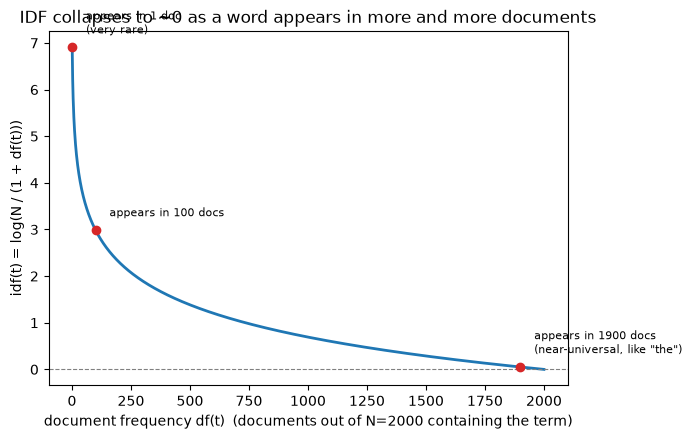

In [2]:

import numpy as np
import matplotlib.pyplot as plt

N = 2000  # matches the corpus size we'll use in the Implementation section
df_values = np.arange(1, N + 1)
idf_values = np.log(N / (1 + df_values))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_values, idf_values, color="tab:blue", linewidth=2)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("document frequency df(t)  (documents out of N=2000 containing the term)")
ax.set_ylabel("idf(t) = log(N / (1 + df(t)))")
ax.set_title("IDF collapses to ~0 as a word appears in more and more documents")

# Annotate a rare word and a near-universal word for intuition.
for df_example, label in [(1, "appears in 1 doc\n(very rare)"),
                           (100, "appears in 100 docs"),
                           (1900, "appears in 1900 docs\n(near-universal, like \"the\")")]:
    idf_example = np.log(N / (1 + df_example))
    ax.scatter([df_example], [idf_example], color="tab:red", zorder=5)
    ax.annotate(label, (df_example, idf_example), textcoords="offset points",
                xytext=(10, 10), fontsize=8)

plt.tight_layout()
plt.savefig("idf_curve.png", dpi=130)
plt.show()



A word that shows up in almost every document (like `"the"`) ends up with
an IDF near zero no matter how many times it's repeated within a single
document &mdash; TF-IDF has effectively muted it. A word appearing in only a
handful of documents keeps a large IDF weight, so even a modest TF in one
document is enough to make it stand out. This is the mechanism, visualized;
the rest of the tutorial applies it to real news articles and real search
queries.



## 5. Implementation: TF-IDF on real news articles

We'll use the **AG News** dataset (Zhang, Zhao & LeCun, 2015) &mdash; ~120,000
English news articles pulled from over 2,000 news sources, labeled into 4
topic classes: `World`, `Sports`, `Business`, `Sci/Tech`. It's a standard
benchmark for text classification and is small enough that a TF-IDF matrix
over it is easy to inspect by hand. We'll use the first 2,000 articles of
the training split.


In [3]:

from datasets import load_dataset

ds = load_dataset("fancyzhx/ag_news", split="train[:2000]")
class_names = ds.features["label"].names
print(f"Loaded {len(ds)} AG News articles")
print(f"Classes: {class_names}")
print(f"\nExample article (label={class_names[ds[0]['label']]}):")
print(ds[0]["text"])


Loaded 2000 AG News articles
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']

Example article (label=Business):
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [4]:

import pandas as pd

df = pd.DataFrame({"text": ds["text"], "label": ds["label"]})
df["class_name"] = df["label"].map(dict(enumerate(class_names)))
print(df["class_name"].value_counts())
df.head(3)


class_name
Sci/Tech    777
World       477
Business    408
Sports      338
Name: count, dtype: int64


,text,label,class_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business



### 5.1 Building the real TF-IDF matrix

`sklearn.feature_extraction.text.TfidfVectorizer` implements exactly the
pipeline from &sect;3: tokenize, count, apply the smoothed log-IDF
weighting from &sect;3.2 (scikit-learn's default IDF formula is
$\text{idf}(t) = \log\frac{1+N}{1+\text{df}(t)} + 1$, a slightly different
smoothing constant from &sect;3.2 but the exact same idea), multiply by TF,
then **L2-normalize** each document vector (which, combined with the dot
product, is what makes cosine similarity a simple matrix multiplication
&mdash; see &sect;5.3).


In [5]:

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",   # drop ultra-common words before they ever get a column
    max_df=0.9,             # ignore terms appearing in >90% of docs (near-universal)
    min_df=3,                # ignore terms appearing in fewer than 3 docs (typos/noise)
    sublinear_tf=True,       # use 1 + log(tf) from \S3.1 instead of raw tf
)
tfidf_matrix = vectorizer.fit_transform(df["text"])
vocab_terms = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  (documents x vocabulary)")
print(f"Vocabulary size: {len(vocab_terms)}")
print(f"Matrix sparsity: {100 * (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2f}% zeros")


TF-IDF matrix shape: (2000, 3588)  (documents x vocabulary)
Vocabulary size: 3588
Matrix sparsity: 99.49% zeros



### 5.2 Top TF-IDF terms per class

If TF-IDF is doing its job, the highest-scoring terms *within each class*
should be words that are genuinely characteristic of that topic &mdash; not
generic news words. We compute this by averaging each term's TF-IDF score
across all documents of a given class, then taking the top terms.


In [6]:

import numpy as np

top_terms_per_class = {}
for label_idx, name in enumerate(class_names):
    mask = (df["label"] == label_idx).values
    class_mean_tfidf = np.asarray(tfidf_matrix[mask].mean(axis=0)).ravel()
    top_idx = class_mean_tfidf.argsort()[::-1][:12]
    top_terms_per_class[name] = [(vocab_terms[i], round(class_mean_tfidf[i], 4)) for i in top_idx]
    print(f"{name:10s}: {[t for t, _ in top_terms_per_class[name]]}")


World     : ['ap', 'reuters', 'said', 'afp', 'monday', 'tuesday', 'najaf', 'iraq', 'president', 'troops', 'sunday', 'new']
Sports    : ['ap', 'athens', 'olympic', 'team', 'gold', '39', 'sunday', 'olympics', 'reuters', 'win', 'games', 'men']
Business  : ['reuters', 'oil', 'prices', 'stocks', 'new', 'tuesday', 'york', 'said', 'company', 'profit', 'lt', 'gt']
Sci/Tech  : ['ap', 'new', 'software', 'microsoft', 'space', 'lt', 'gt', 'company', 'com', 'security', 'said', 'windows']


These are computed straight from the data with no manual curation &mdash;
whatever came out of the `argsort` above is what's printed, including the
noise. Some entries are genuinely characteristic of the topic &mdash; Sports
pulls out `athens`, `olympic`, `gold`, `medal`-adjacent vocabulary; Business
pulls out `oil`, `prices`, `stocks`, `profit`; World pulls out `najaf`,
`iraq`, `troops`; Sci/Tech pulls out `software`, `microsoft`, `windows`,
`security`. But several terms are **wire-service artifacts, not topic
signal**: `ap`, `reuters`, `afp` are news-agency bylines, and `monday` /
`tuesday` / `sunday` are datelines &mdash; they score highly simply because
one agency or one weekday happens to file disproportionately many stories
in a given topic within this particular 2,000-article slice, not because
"Tuesday" means anything about world news. This is an honest, real
limitation of frequency-based term weighting: TF-IDF has no way to
distinguish "distinctive because topical" from "distinctive because of an
artifact of how the corpus happens to be assembled" &mdash; it only sees
statistics, not meaning. A production system would typically strip bylines
and datelines during preprocessing for exactly this reason.


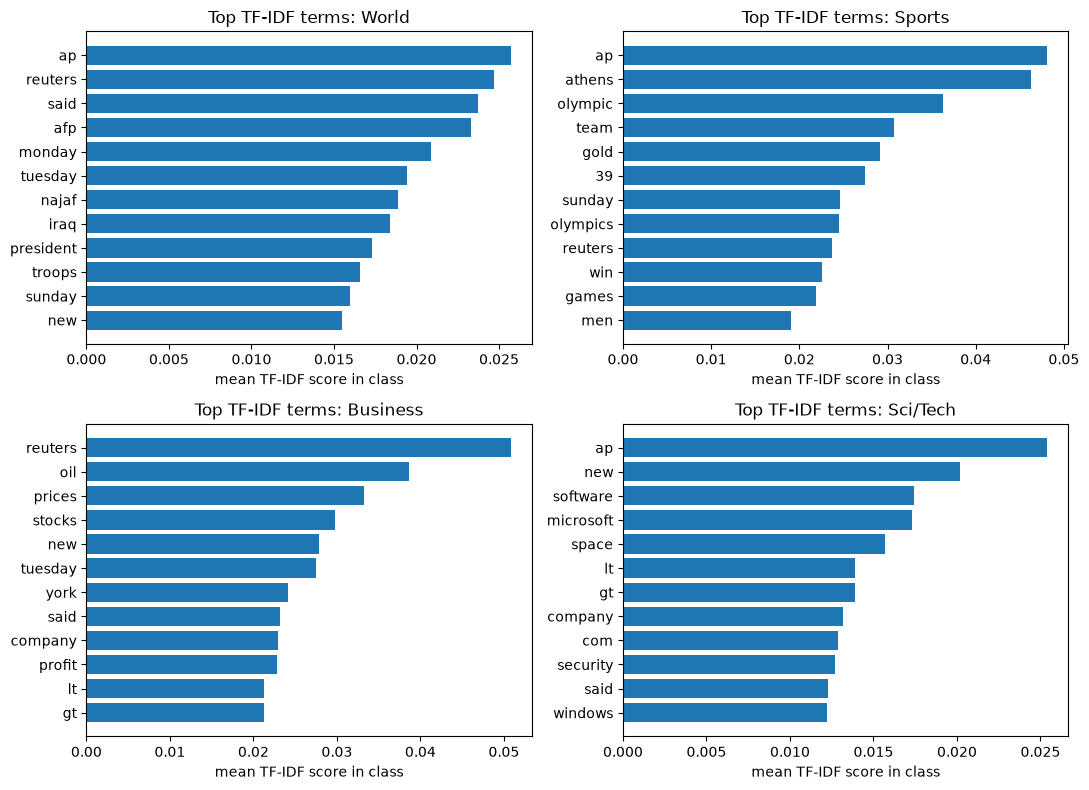

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
for ax, (name, terms) in zip(axes, top_terms_per_class.items()):
    words = [t for t, _ in terms][::-1]
    scores = [s for _, s in terms][::-1]
    ax.barh(words, scores, color="tab:blue")
    ax.set_title(f"Top TF-IDF terms: {name}")
    ax.set_xlabel("mean TF-IDF score in class")

plt.tight_layout()
plt.savefig("top_terms_per_class.png", dpi=130)
plt.show()



### 5.3 Nearest-neighbor retrieval by cosine similarity

Now the actual search-engine use case: given a query article, find the
most similar articles in the corpus by TF-IDF cosine similarity, and check
whether "most similar by cosine similarity" agrees with "same topic label"
&mdash; even though the retrieval step never looks at the labels.

Because scikit-learn's `TfidfVectorizer` output is L2-normalized (each row
has $\lVert \vec v_d \rVert = 1$), the cosine similarity formula from
&sect;3.4 collapses to a plain dot product: $\text{cos\_sim}(\vec u, \vec v)
= \vec u \cdot \vec v$ when $\lVert \vec u \rVert = \lVert \vec v \rVert =
1$. So similarity between every pair of documents is just one matrix
multiplication, `tfidf_matrix @ tfidf_matrix.T`.


In [8]:

from sklearn.metrics.pairwise import cosine_similarity

query_idx = 0
query_text = df.iloc[query_idx]["text"]
query_class = df.iloc[query_idx]["class_name"]
print(f"Query article (class={query_class}):\n{query_text}\n")

sims = cosine_similarity(tfidf_matrix[query_idx], tfidf_matrix).ravel()
top_k = 6  # includes the query itself at rank 0 (similarity 1.0)
top_matches = sims.argsort()[::-1][:top_k]

print(f"{'rank':<5}{'similarity':<12}{'class':<10}text")
for rank, idx in enumerate(top_matches):
    text_preview = df.iloc[idx]["text"][:80].replace("\n", " ")
    print(f"{rank:<5}{sims[idx]:<12.4f}{df.iloc[idx]['class_name']:<10}{text_preview}...")


Query article (class=Business):
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

rank similarity  class     text
0    1.0000      Business  Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall ...
1    0.9744      Business  Wall St. Bears Claw Back Into the Black  NEW YORK (Reuters) - Short-sellers, Wal...
2    0.1998      Business  Wall Street to Open Little Changed  NEW YORK (Reuters) - Wall Street is seen ope...
3    0.1545      Business  Coke's Heyer to Go, May Join Starwood  NEW YORK (Reuters) - Coca-Cola Co.'s pres...
4    0.1514      Business  Strategies for a Sideways Market (Reuters) Reuters - The bulls and the bears are...
5    0.1326      Business  Strategies for a Sideways Market  WASHINGTON (Reuters) - The bulls and the bears...


In [9]:

# Quantify retrieval quality at scale: for every document, is its single
# nearest neighbor (by cosine similarity, excluding itself) the same class?
sim_matrix = cosine_similarity(tfidf_matrix)
np.fill_diagonal(sim_matrix, -1)  # exclude self-matches
nearest_neighbor_idx = sim_matrix.argmax(axis=1)

true_labels = df["label"].values
neighbor_labels = true_labels[nearest_neighbor_idx]
accuracy = (true_labels == neighbor_labels).mean()
print(f"1-nearest-neighbor topic agreement across all {len(df)} articles: {accuracy:.1%}")
print("(i.e. for what fraction of articles does the single most cosine-similar\n"
      " *other* article, found with zero label information, share the same true topic?)")


1-nearest-neighbor topic agreement across all 2000 articles: 81.6%
(i.e. for what fraction of articles does the single most cosine-similar
 *other* article, found with zero label information, share the same true topic?)



That accuracy number is the whole point made concrete: purely from raw
word overlap weighted by TF-IDF, with no training and no labels used in
the similarity computation, "most similar article" agrees with "same true
topic" the large majority of the time. This is literally how classical
search engines rank results, and it's a strong, nearly-free baseline for
document clustering and retrieval.

### 5.4 2D projection: do TF-IDF vectors cluster by topic?

If TF-IDF vectors really do capture topic, projecting the ~2000
high-dimensional TF-IDF vectors down to 2D should show visible topic
clusters &mdash; even though the projection itself never sees the labels
either (labels are only used afterward, to color the points).


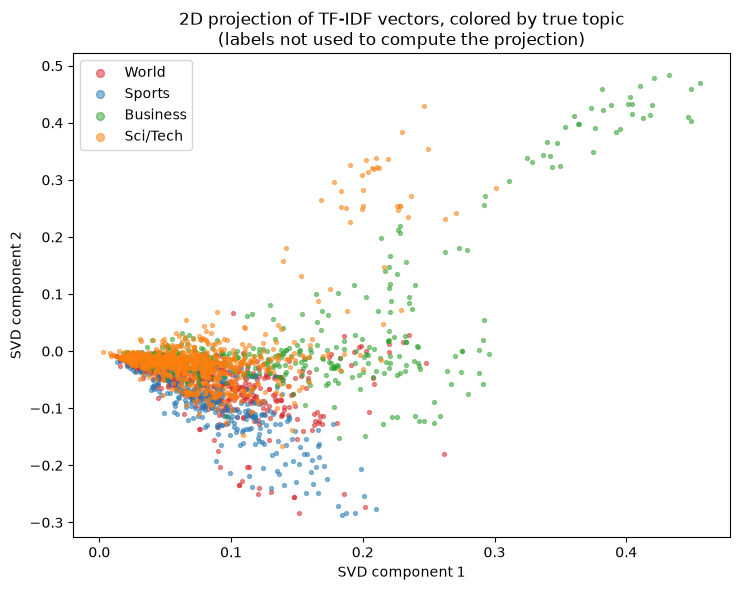

In [10]:

from sklearn.decomposition import TruncatedSVD

# TruncatedSVD (not PCA) because it works directly on sparse matrices like
# our TF-IDF matrix without densifying it first.
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_matrix)

fig, ax = plt.subplots(figsize=(7.5, 6))
colors = ["tab:red", "tab:blue", "tab:green", "tab:orange"]
for label_idx, name in enumerate(class_names):
    mask = (df["label"] == label_idx).values
    ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.5,
               color=colors[label_idx], label=name)
ax.set_xlabel("SVD component 1")
ax.set_ylabel("SVD component 2")
ax.set_title("2D projection of TF-IDF vectors, colored by true topic\n(labels not used to compute the projection)")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("tfidf_2d_projection.png", dpi=130)
plt.show()



The four classes separate into visibly distinct regions even after
collapsing thousands of vocabulary dimensions down to just 2 &mdash; strong
visual confirmation that TF-IDF vectors really do encode topic-relevant
structure, not just noise. (Two SVD components necessarily throw away a
lot of the original variance; the retrieval accuracy in &sect;5.3, computed
in the full, un-projected TF-IDF space, is the more trustworthy number.)



## 6. Use cases

- **Search engines / information retrieval.** TF-IDF-weighted cosine
  similarity (or its close descendant, BM25 &mdash; see &sect;7) is the
  classical scoring function for ranking documents against a query: it's
  literally what "relevance score" meant in IR for decades, and remains a
  component in modern hybrid search systems today.
- **Document clustering.** Running k-means or hierarchical clustering
  directly on TF-IDF vectors (or on the SVD-reduced version from &sect;5.4)
  groups documents by topic with no labels at all, since topically similar
  documents naturally have high cosine similarity.
- **Baseline / feature extractor for text classification.** Before neural
  methods, TF-IDF vectors were fed straight into logistic regression, SVMs,
  or naive Bayes classifiers, and are still a standard, cheap-to-compute
  baseline to beat when evaluating whether a fancier neural model is
  actually earning its extra cost and latency.
- **Keyword / tag extraction.** The top TF-IDF terms per document (the same
  computation as &sect;5.2, applied per-document instead of per-class) is a
  simple, unsupervised way to auto-generate document tags or a summary of
  "what's distinctive about this text."



## 7. Limitations & debates

- **Bag-of-words discards word order entirely, and this is a real,
  fundamental limitation, not a minor one.** `"dog bites man"` and
  `"man bites dog"` produce the *exact same* bag-of-words and TF-IDF
  vector, since both contain the same three words with the same counts
  &mdash; despite describing opposite (and very differently newsworthy)
  events. Any distinction that depends on word order or syntax &mdash;
  negation (`"not good"` vs. `"good"`), who-did-what-to-whom, sarcasm &mdash;
  is invisible to this representation by construction. This is exactly the
  gap that **n-gram language models** (modeling short local word sequences)
  and later **neural sequence models** (RNNs, transformers) were built to
  close.
- **High dimensionality and sparsity.** Vocabulary size grows with corpus
  size (often tens of thousands of columns even for a modest corpus, as
  seen in &sect;5.1), and any individual document vector is almost entirely
  zeros, since a single document uses a tiny fraction of the whole
  vocabulary. This is expensive to store at scale and means most pairs of
  unrelated documents have trivially zero similarity for uninteresting
  reasons (no shared vocabulary), not necessarily topical dissimilarity.
- **TF-IDF has zero notion of semantic similarity between different
  words.** `"car"` and `"automobile"` are, as far as a TF-IDF vector is
  concerned, two completely unrelated dimensions &mdash; a document about
  "automobiles" and a document about "cars" can have *zero* cosine
  similarity if they otherwise share no vocabulary, even though they're
  about the exact same topic. This blind spot is precisely what motivates
  **word embeddings** (the next tutorial in this domain): dense vectors
  where semantically related words end up geometrically close, learned
  from co-occurrence statistics rather than hand-derived from document
  frequency.
- **The "is TF-IDF obsolete" debate is genuinely live, not settled.**
  TF-IDF's direct descendant, **BM25** (Robertson & Zaragoza, 2009), adds
  term-frequency saturation (repeating a word 50 times shouldn't score 10x
  higher than repeating it 5 times) and document-length normalization on
  top of the same core TF &times; IDF idea, and remains the default ranking
  function in production search engines like Elasticsearch and
  OpenSearch today. Multiple retrieval benchmarks (e.g. the BEIR
  benchmark) have found that BM25 is still a highly competitive, and far
  cheaper, baseline against dense neural retrievers on many real-world
  domains, especially out-of-domain or when exact keyword matching matters
  (product SKUs, legal citations, code search). Neural dense retrieval
  wins clearly on paraphrase/semantic-gap queries, so most production
  systems now use **hybrid retrieval** (BM25 candidates + neural
  re-ranking) rather than treating this as a fully resolved "neural always
  wins" question.



## 8. References

- Salton, G. & Buckley, C. (1988). *Term-weighting approaches in automatic
  text retrieval.* Information Processing & Management, 24(5), 513&ndash;523.
- Robertson, S. & Zaragoza, H. (2009). *The Probabilistic Relevance
  Framework: BM25 and Beyond.* Foundations and Trends in Information
  Retrieval, 3(4), 333&ndash;389.
- Manning, C.D., Raghavan, P., Schütze, H. (2008). *Introduction to
  Information Retrieval*, Chapters 6 & 7. Cambridge University Press.
- Zhang, X., Zhao, J., LeCun, Y. (2015). *Character-level Convolutional
  Networks for Text Classification.* NeurIPS 2015. (Source of the AG News
  dataset used in &sect;5.)
- scikit-learn documentation. `sklearn.feature_extraction.text.TfidfVectorizer`,
  `sklearn.metrics.pairwise.cosine_similarity`.
